# Лабораторная работа 5. Временные ряды. 


Результат лабораторной работы &mdash; отчет. Мы предпочитаем принимать отчеты в формате ноутбуков IPython (ipynb-файл). Постарайтесь сделать ваш отчет интересным рассказом, последовательно отвечающим на вопросы из заданий. Помимо ответов на вопросы, в отчете так же должен быть код, однако чем меньше кода, тем лучше всем: нам &mdash; меньше проверять, вам &mdash; проще найти ошибку или дополнить эксперимент. При проверке оценивается четкость ответов на вопросы, аккуратность отчета и кода.


### Оценивание и штрафы
Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи). Максимально допустимая оценка за работу &mdash; 10 баллов. Сдавать задание после указанного в lk срока сдачи нельзя. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов и понижают карму (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий в открытом источнике, необходимо прислать ссылку на этот источник (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, нам необходима ссылка на источник).



In [2]:
import os
import numpy as np
import pandas as pd
from zipfile import ZipFile

import matplotlib.pyplot as plt
import seaborn as sns
sns.set(palette='Set2')

from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

import statsmodels.api as sm
import pmdarima as pm
from tbats import TBATS

## 1. Данные

В качестве данных рассмотрим известный набор данных с параметрами погоды в одной точке земной поверхности, доступный нам с частотой дискретизации в 10 минут. Описание данных доступно по <a href="https://keras.io/examples/timeseries/timeseries_weather_forecasting/">ссылке</a>.

Скачаем данные

In [3]:
uri = "https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip"
!wget {uri}

--2025-07-13 16:06:05--  https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 64.233.164.207, 108.177.14.207, 74.125.131.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|64.233.164.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13568290 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  10.2MB/s    in 1.3s    

2025-07-13 16:06:07 (10.2 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13568290/13568290]



In [4]:
zip_path = "jena_climate_2009_2016.csv.zip"
assert os.path.exists(zip_path), f"Download {uri}"

zip_file = ZipFile(zip_path)
zip_file.extractall()
csv_path = "jena_climate_2009_2016.csv"

Немного преобразуем данные, рассмотрев максимальное значение каждой величины за сутки.

In [5]:
csv_path = "jena_climate_2009_2016.csv"
weather_df = pd.read_csv(csv_path)
weather_df["Date"] = pd.to_datetime(weather_df["Date Time"], format="%d.%m.%Y %H:%M:%S")

weather_df_daily = weather_df.set_index("Date").resample('D').max().reset_index()
del weather_df_daily["Date Time"]
weather_df_daily = weather_df_daily.set_index('Date')
weather_df_daily.head()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date,,,,,,,,,,,,,,
2009-01-01,1000.87,-4.17,269.00,-5.36,94.8,4.48,4.09,0.49,2.55,4.09,1318.81,2.51,3.63,357.9
2009-01-02,1002.65,-2.12,271.12,-3.88,96.3,5.22,4.58,0.70,2.86,4.59,1298.51,3.87,6.13,358.8
2009-01-03,1002.49,-0.82,272.59,-6.09,93.9,5.75,3.87,2.86,2.41,3.86,1323.70,3.64,4.88,357.2
2009-01-04,992.93,-0.63,273.55,-2.26,93.9,5.83,5.17,1.53,3.27,5.25,1274.06,3.95,7.13,257.0
2009-01-05,997.54,-1.44,272.89,-2.45,93.2,5.49,5.10,0.83,3.23,5.18,1332.38,7.81,10.88,358.9


Теперь в каждой строчке датасета мы имеем максимальные значения за сутки. Например, в строчке `2012-12-22` в колонке `T (degC)` записана максимальная температура по Цельсию за данные сутки.

**Глобальная цель** в данном домашнем задании &mdash; прогнозирование максимальной температуры на день вперед. Например, 22 декабря нужно построить прогноз значения `T (degC)` за 23 декабря, используя при этом любые данные до 22 декабря включительно, но не используя никакие данные начиная с 23 декабря.

*Замечание*. Обратите внимание, что значения от 22 декабря доступны только по окончанию этого дня, плюс накладные расходы на поставку данных. Но для упрощения ситуации, допустим, что данные приходят мгновенно, а прогноз от нас ждут в начале суток 23 декабря, так что мы успеем подучить данные от 22 декабря, преобразовать их в признаки и применить нашу модель.

#### Задача 1. [0.25 балла]

Выделите таргет в отдельную переменную `pd.Series`. Значением таргета от 22 декабря должна быть максимальная температура за сутки 23 декабря, то есть то, что мы хотим прогнозировать.

Разделите данные на обучающие и тестовые. В качестве тестового отрезка времени возьмите данные за последний год. Обратите внимание, что за 2016-10-26 и 2016-10-27 данных нет.

In [6]:
weather_df_daily = weather_df_daily.sort_index()
weather_df_daily.index = pd.to_datetime(weather_df_daily.index)
y = weather_df_daily['T (degC)'].shift(-1).rename('T_next_day')

In [7]:
full_range = pd.date_range(start=weather_df_daily.index.min(),
                           end=weather_df_daily.index.max(), freq='D')
weather_df_daily = weather_df_daily.reindex(full_range)

# Заполняем пропуски полиномиальной интерполяцией
weather_df_daily['T (degC)'] = weather_df_daily['T (degC)'].interpolate(method='polynomial', order = 3)
y = weather_df_daily['T (degC)'].shift(-1).rename('T_next_day')
weather_df_daily = weather_df_daily.iloc[:-1]
y = y.iloc[:-1]

разбиение на test и train логичнее делать после преобразования данных

## 2. Простая аналитика

#### Задача 2. [0.5 балла]

Произведите визуализацию всех временных рядов.

Имеются ли в данных выбросы? Если да, отфильтруйте данные. Не перестарайтесь, фильтруйте только более менее очевидные выбросы.

Подумайте над тем, какие значения ставить вместо выбросов. Учтите, что не все модели могут обрабатывать пропуски.

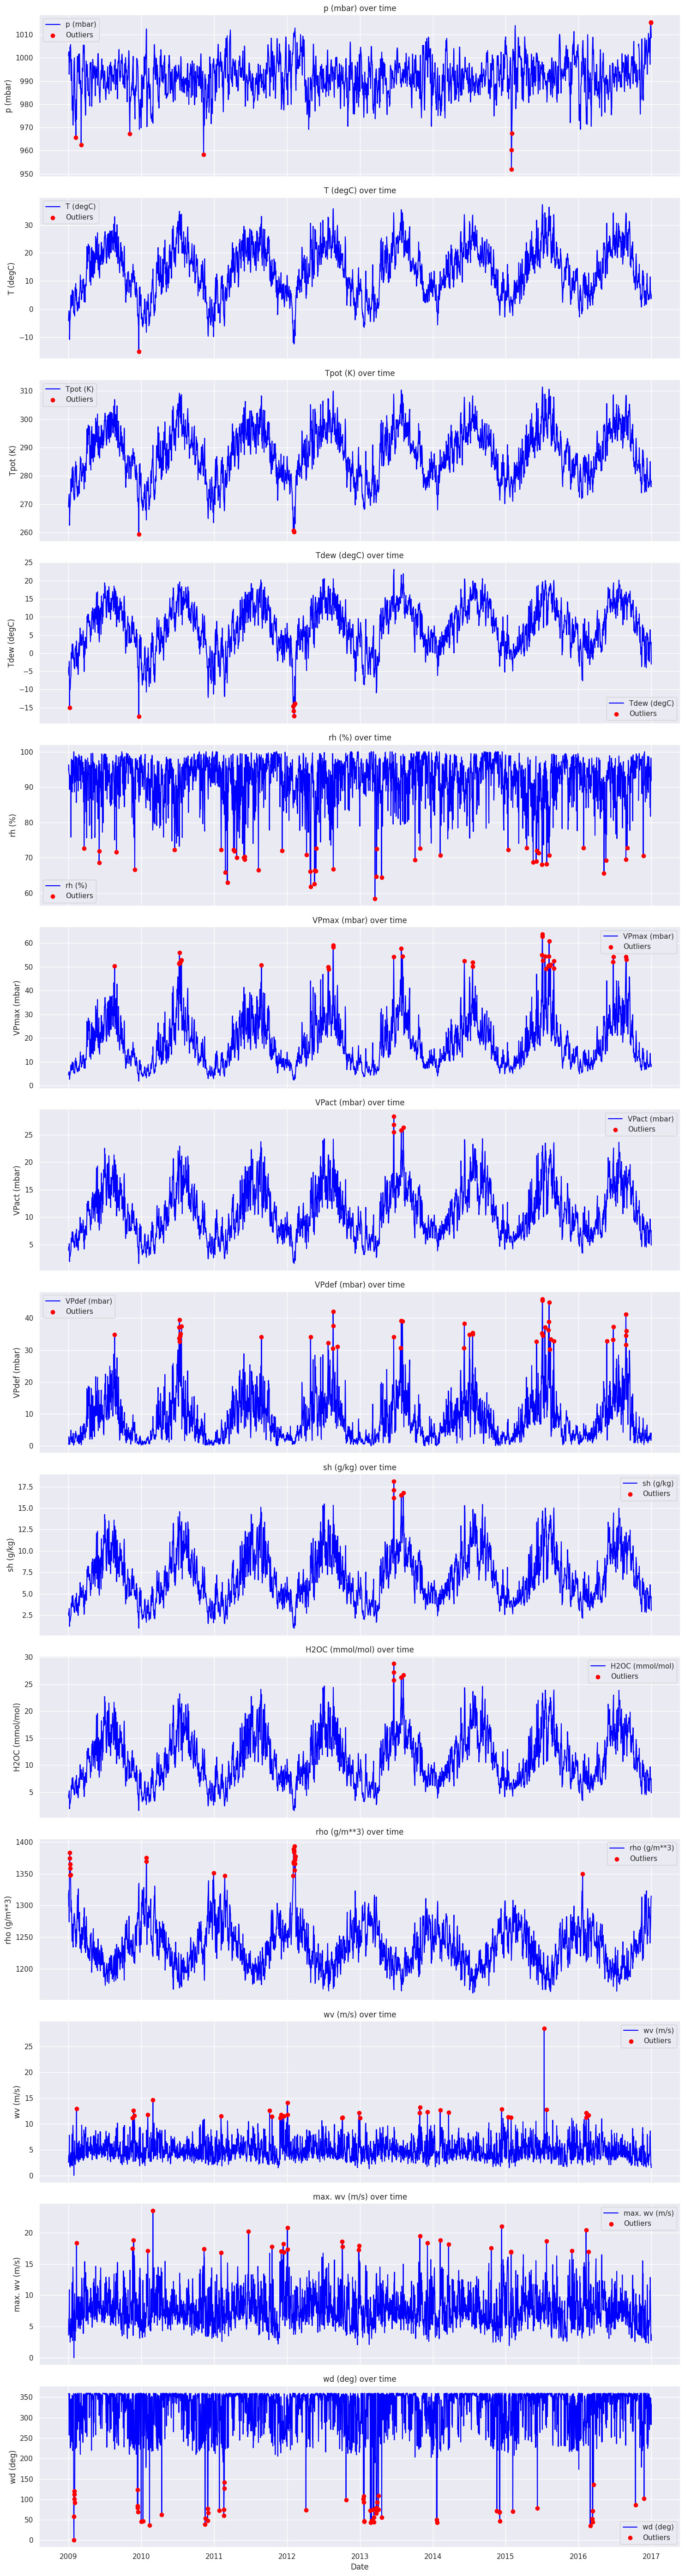

In [9]:
import matplotlib.pyplot as plt

weather_df_daily.index = pd.to_datetime(weather_df_daily.index)
numeric_cols = weather_df_daily.select_dtypes(include='number').columns

def detect_outliers_zscore(series, threshold=3):
    mean = series.mean()
    std = series.std()
    return (series - mean).abs() > threshold * std

fig, axes = plt.subplots(len(numeric_cols), 1, figsize=(15, 4 * len(numeric_cols)), sharex=True)

if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    series = weather_df_daily[col]
    outliers_mask = detect_outliers_zscore(series)

    # Основной график
    axes[i].plot(series.index, series, label=col, color='blue')

    # Выбросы
    axes[i].scatter(series.index[outliers_mask], series[outliers_mask],
                    color='red', label='Outliers', zorder=3)

    axes[i].set_title(f'{col} over time')
    axes[i].set_ylabel(col)
    axes[i].legend()
    axes[i].grid(True)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


#### Задача 3. [0.5 балла]

Посчитайте матрицу корреляций по всем временным рядам без сдвигов (т.е. $corr(x_t, y_t)$) и визуализируйте ее

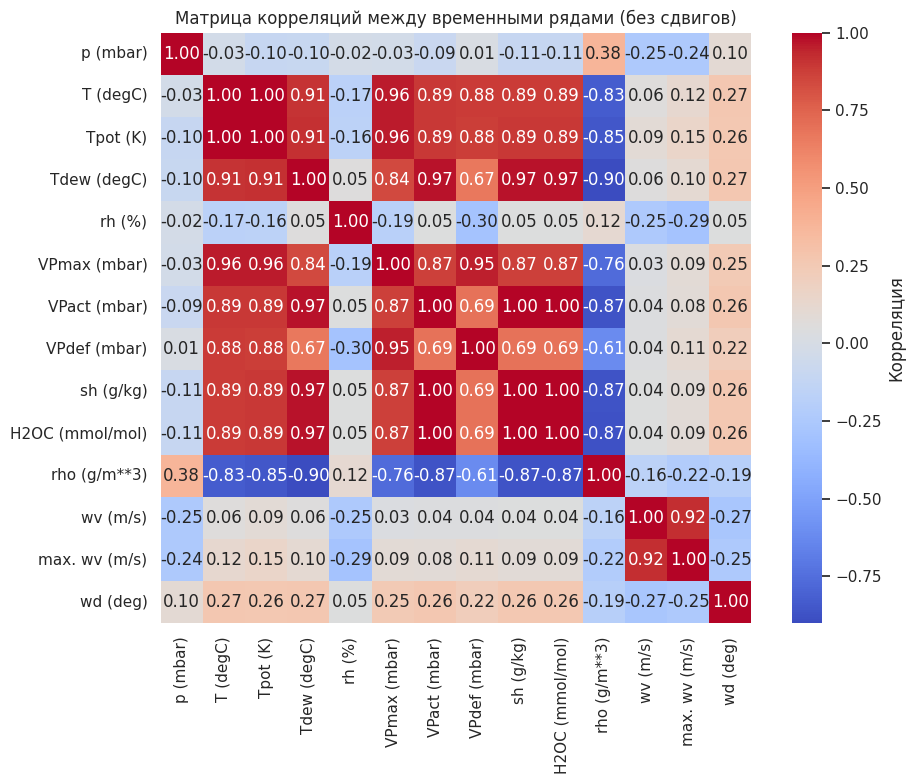

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = weather_df_daily.select_dtypes(include='number')

corr_matrix = numeric_df.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            cbar_kws={'label': 'Корреляция'})
plt.title('Матрица корреляций между временными рядами (без сдвигов)')
plt.tight_layout()
plt.show()


По временному ряду температуры выполните STL-разложение и визуализируйте полученные компоненты

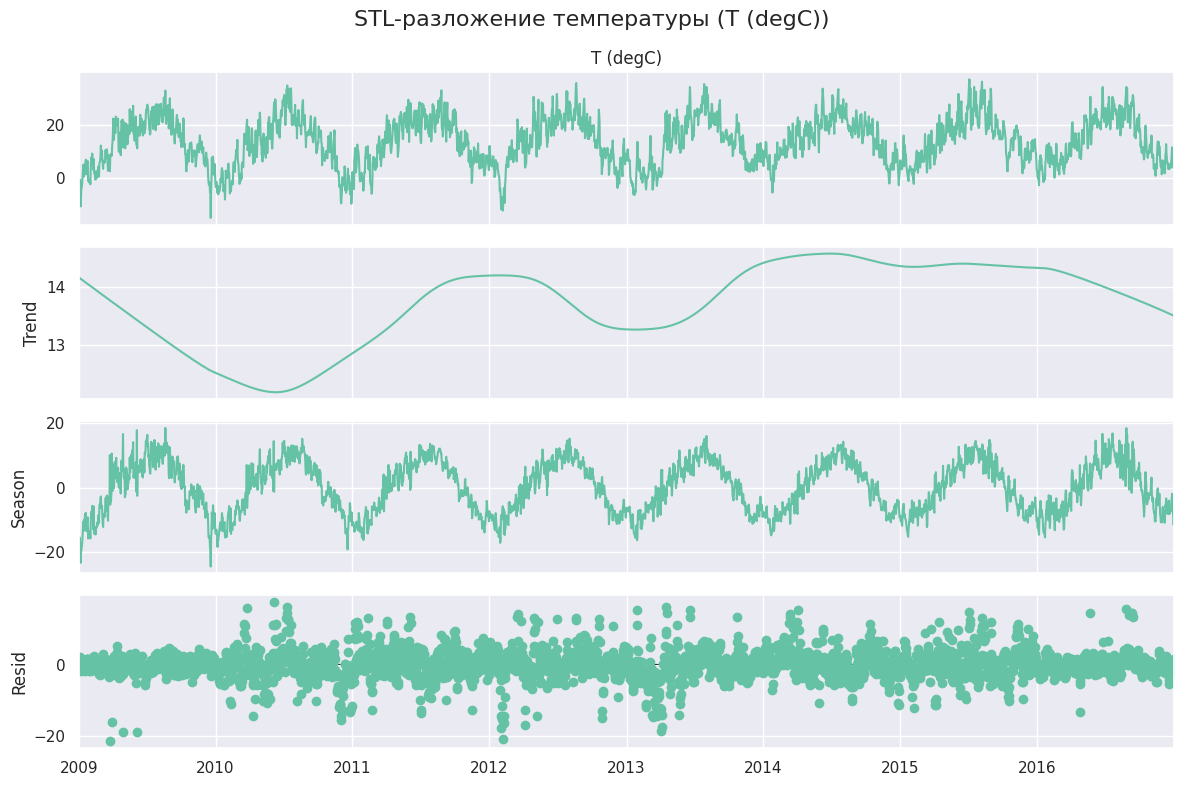

In [10]:
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt

weather_df_daily.index = pd.to_datetime(weather_df_daily.index)
temperature_series = weather_df_daily['T (degC)'].dropna()

stl = STL(temperature_series, period=365, robust=True)
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)
fig.suptitle('STL-разложение температуры (T (degC))', fontsize=16)
plt.tight_layout()
plt.show()


In [11]:
#интерполиуруем выбросы в этих столбцах, т.к будем их использовать для предсказания
for column in ['p (mbar)', 'T (degC)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']:
    T_series = weather_df_daily[column].copy()
    outliers_mask = detect_outliers_zscore(T_series)
    T_series[outliers_mask] = np.nan
    T_series_interpolated = T_series.interpolate(method='polynomial', order=3)
    weather_df_daily[column] = T_series_interpolated

#также интерполируем выбросы в y
T_series = y
outliers_mask = detect_outliers_zscore(T_series)
T_series[outliers_mask] = np.nan
T_series_interpolated = T_series.interpolate(method='polynomial', order=3)
y = T_series_interpolated

In [12]:
#разбиение на train и test
last_date = weather_df_daily.index.max()
test_start = last_date - pd.DateOffset(years=1) + pd.Timedelta(days=1)
test_end = last_date 

valid_rows = y.notna()


X_train = weather_df_daily.loc[(weather_df_daily.index < test_start) & valid_rows]
y_train = y.loc[(y.index < test_start) & valid_rows]

X_test = weather_df_daily.loc[(weather_df_daily.index >= test_start) & 
                              (weather_df_daily.index <= test_end) & valid_rows]
y_test = y.loc[(y.index >= test_start) & (y.index <= test_end) & valid_rows]


**Выводы:** тренда не наблюдается, зато четко видна годовая сезонность.  Матрица корреляций показывает, что много признаков коррелируют друг с другом

## 3. Качество

#### Задача 4. [1 балл]

Напишите функции вычисления качества решения в задачи прогнозирования.
Качество решения будем описывать при помощи нескольких метрик качества:
  * mean_squared_error
  * mean_absolute_error
  * median_absolute_error

In [13]:
import numpy as np

def evaluate_forecast(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    mse = np.mean((y_true - y_pred)**2)
    mae = np.mean(np.abs(y_true - y_pred))
    medae = np.median(np.abs(y_true - y_pred))
    
    return {
        'MSE': mse,
        'MAE': mae,
        'MedAE': medae
    }


По всем тестовым данным посчитайте метрики качества baseline-решения &mdash; наивной модели. Попробуйте варианты:
- Naive(1): прогноз лагом порядка 1, т.е. последним доступным значением;
- Naive(2): прогноз лагом порядка 2;
- Naive(3): прогноз лагом порядка 3.

Обратите внимание на наличие пропусков в целевой переменной, как лучше поступить с ними при оценке качества и при построении прогноза?

In [14]:
results = {}

for lag in [1, 2, 3]:
    y_pred_naive = X_test['T (degC)'].shift(lag)  # сдвигаем назад на lag
    y_pred_naive = y_pred_naive.loc[y_test.index].dropna()
    y_true_aligned = y_test.loc[y_pred_naive.index]

    results[f'Naive({lag})'] = evaluate_forecast(y_true_aligned, y_pred_naive)

# Вывод результатов
for model, metrics in results.items():
    print(f'📊 {model}:')
    for metric, value in metrics.items():
        print(f'  {metric}: {value:.4f}')

📊 Naive(1):
  MSE: 19.3400
  MAE: 3.4070
  MedAE: 2.6400
📊 Naive(2):
  MSE: 25.8615
  MAE: 4.0590
  MedAE: 3.3650
📊 Naive(3):
  MSE: 31.3310
  MAE: 4.4900
  MedAE: 3.9700


Посчитайте по всем моделям эти же метрики по скользящим окнам из 4 и 8 недель:
- Берем тестовый промежуток и разбиваем его на окна, состоящие из 4 недель. Следующее окно сдвинуто относительно предыдущего на 1 день.
- По каждой модели считаем метрики одношагового прогноза на выбранном окне.
- Аналогично повторяем для окон из 8 недель.

Таким образом, для каждой модели получатся последовательности метрик по окнам. Постройте графики изменения качества прогноза.

In [15]:
def rolling_metrics(X_test, y_test, window_days=28, lags=[1, 2, 3]):
    start = X_test.index.min()
    end = X_test.index.max() - pd.Timedelta(days=1)  # чтобы y_t+1 существовал
    results = {f'Naive({lag})': [] for lag in lags}
    dates = []

    current = start
    while current + pd.Timedelta(days=window_days) <= end:
        window_start = current
        window_end = current + pd.Timedelta(days=window_days)
        
        X_window = X_test.loc[window_start:window_end]
        y_window = y_test.loc[window_start:window_end]

        for lag in lags:
            y_pred = X_window['T (degC)'].shift(lag).loc[y_window.index]
            valid_idx = y_pred.dropna().index
            metrics = evaluate_forecast(y_window.loc[valid_idx], y_pred.loc[valid_idx])
            results[f'Naive({lag})'].append(metrics)
        
        dates.append(window_end)
        current += pd.Timedelta(days=1)

    return pd.DataFrame({
        (model, metric): [m[metric] for m in values]
        for model, values in results.items()
        for metric in ['MSE', 'MAE', 'MedAE']
    }, index=dates)


rolling_4w = rolling_metrics(X_test, y_test, window_days=28)
rolling_8w = rolling_metrics(X_test, y_test, window_days=56)

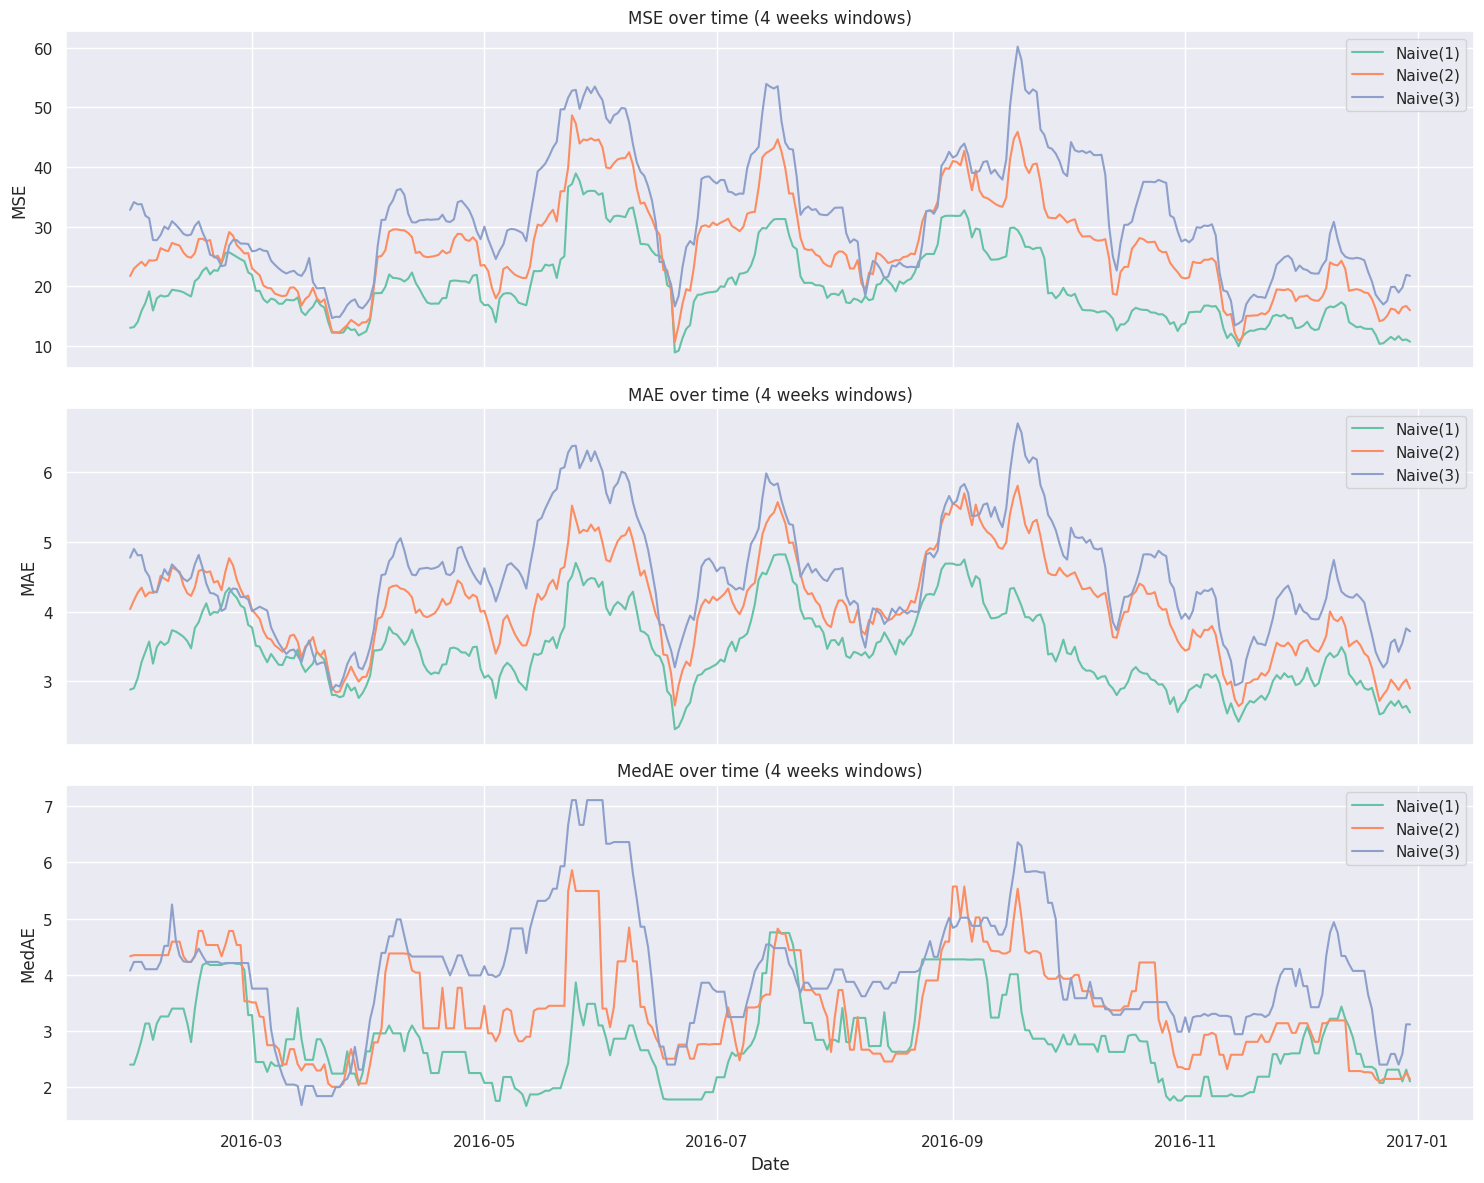

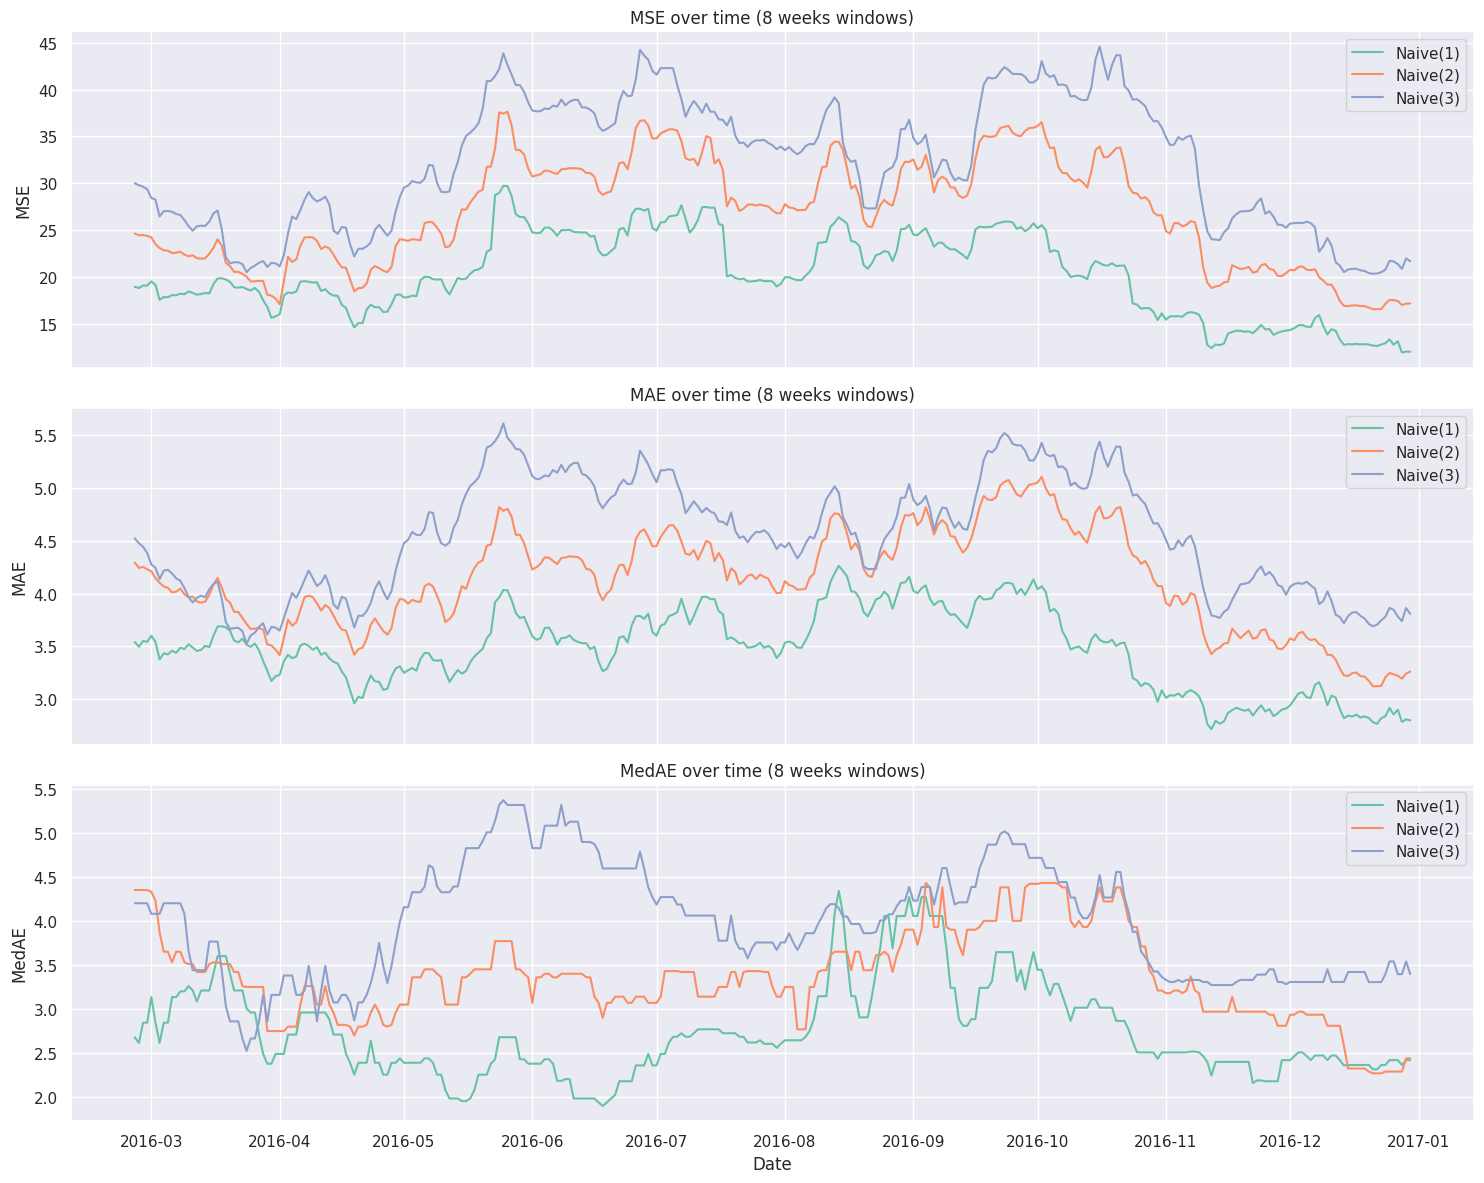

In [16]:
import matplotlib.pyplot as plt

def plot_rolling_metrics(rolling_df, window_label='4 weeks'):
    metrics = ['MSE', 'MAE', 'MedAE']
    models = ['Naive(1)', 'Naive(2)', 'Naive(3)']

    fig, axes = plt.subplots(len(metrics), 1, figsize=(15, 4 * len(metrics)), sharex=True)

    if len(metrics) == 1:
        axes = [axes]

    for i, metric in enumerate(metrics):
        ax = axes[i]
        for model in models:
            ax.plot(rolling_df.index, rolling_df[(model, metric)], label=model)
        ax.set_title(f'{metric} over time ({window_label} windows)')
        ax.set_ylabel(metric)
        ax.grid(True)
        ax.legend()

    axes[-1].set_xlabel('Date')
    plt.tight_layout()
    plt.show()

# Визуализация метрик по 4-недельным окнам
plot_rolling_metrics(rolling_4w, window_label='4 weeks')

# Визуализация метрик по 8-недельным окнам
plot_rolling_metrics(rolling_8w, window_label='8 weeks')


**Выводы:** видно, что ошибки зависят от периодов. но в целом каких-то прям экстремальных периодов не видно

#### Задача 5. [0.5 балла]

Скользящая валидация с фиксированным началом обучающего периода (*см. в лекциях вариант 1*) реализована в <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html">sklearn.model_selection.TimeSeriesSplit</a>:

In [17]:
from sklearn.model_selection import TimeSeriesSplit


ts_cv_1 = TimeSeriesSplit(n_splits=5, test_size=8*7)

Варианта с фиксированным размером обучающего датасета (*см. в лекциях вариант 2*) тоже можно добиться при помощи <a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html">sklearn.model_selection.TimeSeriesSplit</a>:

In [18]:
ts_cv_2 = TimeSeriesSplit(n_splits=5, max_train_size=1000, test_size=8*7)

Пусть вы хотите добиться двух целей:
- Подобрать лучшую модель при помощи поиска оптимальных гиперпараметров.
- Получить несмещенную оценку качества полученной лучшей модели.

Для этих целей лучше не использовать одну и ту же кросс-валидацию, т.к. при подборе гиперепараметров происходит некоторая форма переоптимизации и качество может оказаться несколько завышенным.

С этой целью может подойти вложенная (nested) кросс-валидация, реализацию которого можно найти по <a href="https://github.com/roelbertens/time-series-nested-cv">ссылке</a>, а про читать про нее можно в [посте](https://xebia.com/blog/its-time-to-trust-your-predictions/).

In [19]:
import numpy as np
import pandas as pd

X = weather_df_daily.copy()
y = weather_df_daily['T (degC)'].shift(-1).copy()

def rolling_windows(n_samples, train_size, test_size, step):
    start = 0
    while True:
        train_start = start
        train_end = train_start + train_size
        test_end = train_end + test_size
        if test_end > n_samples:
            break
        yield np.arange(train_start, train_end), np.arange(train_end, test_end)
        start += step

# параметры
outer_train_size = 300
outer_test_size = 60
inner_train_size = 180
inner_test_size = 30

n_samples = len(X)

# внешний цикл
for outer_i, (outer_train_idx, outer_test_idx) in enumerate(
    rolling_windows(n_samples, outer_train_size, outer_test_size, step=60)
):
    print(f"\n===== Outer Fold {outer_i + 1} =====")
    print(f"Outer Train: {outer_train_idx[0]}–{outer_train_idx[-1]}")
    print(f"Outer Test:  {outer_test_idx[0]}–{outer_test_idx[-1]}")

    X_outer_train = X.iloc[outer_train_idx]
    y_outer_train = y.iloc[outer_train_idx]

    # внутренний цикл
    for inner_i, (inner_train_idx, inner_val_idx) in enumerate(
        rolling_windows(len(X_outer_train), inner_train_size, inner_test_size, step=30)
    ):
        print(f"  Inner Fold {inner_i + 1}: Train {inner_train_idx[0]}–{inner_train_idx[-1]}, Val {inner_val_idx[0]}–{inner_val_idx[-1]}")



===== Outer Fold 1 =====
Outer Train: 0–299
Outer Test:  300–359
  Inner Fold 1: Train 0–179, Val 180–209
  Inner Fold 2: Train 30–209, Val 210–239
  Inner Fold 3: Train 60–239, Val 240–269
  Inner Fold 4: Train 90–269, Val 270–299

===== Outer Fold 2 =====
Outer Train: 60–359
Outer Test:  360–419
  Inner Fold 1: Train 0–179, Val 180–209
  Inner Fold 2: Train 30–209, Val 210–239
  Inner Fold 3: Train 60–239, Val 240–269
  Inner Fold 4: Train 90–269, Val 270–299

===== Outer Fold 3 =====
Outer Train: 120–419
Outer Test:  420–479
  Inner Fold 1: Train 0–179, Val 180–209
  Inner Fold 2: Train 30–209, Val 210–239
  Inner Fold 3: Train 60–239, Val 240–269
  Inner Fold 4: Train 90–269, Val 270–299

===== Outer Fold 4 =====
Outer Train: 180–479
Outer Test:  480–539
  Inner Fold 1: Train 0–179, Val 180–209
  Inner Fold 2: Train 30–209, Val 210–239
  Inner Fold 3: Train 60–239, Val 240–269
  Inner Fold 4: Train 90–269, Val 270–299

===== Outer Fold 5 =====
Outer Train: 240–539
Outer Test:  540

Реализуйте вложенную кросс-валидацию. Продемонстрируйте ее работу, распечатав индексы обучающих и тестовых частей во внешнем и внутренних циклах.

*Замечание.* Демонстрацию можете сделать в виде вложенного цикла

## 4. Сведение к задаче регрессии

Для получения признакового описания для конкретного момента времени обычно применяют различные оконные функции к таблице данных, что позволяет сэкономить память и вычисления.
Но нужно помнить, что нельзя допустить просачивание информации из будущего, т.к. такие признаки вы не сможете вычислить в продакшне.




#### Задача 6. [0.5 балла]

Вычислите простые признаки вида описательных статистик (сумма, максимум, минимум, стандартное отклонение) по нескольким размерам окон. Признаки можно вычислять не только по температуре, но и по сопутствующим временным рядам.

In [31]:
X = X_train[['p (mbar)', 'T (degC)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']]
y = y_train
window_sizes = [7, 4*7, 8*7]
numeric_cols = X.select_dtypes(include='number').columns

for col in numeric_cols:
    for w in window_sizes:
        X[f'{col}_sum_{w}'] = X[col].rolling(window=w).sum()
        X[f'{col}_max_{w}'] = X[col].rolling(window=w).max()
        X[f'{col}_min_{w}'] = X[col].rolling(window=w).min()
        X[f'{col}_std_{w}'] = X[col].rolling(window=w).std()
X = X.drop(columns = ['p (mbar)', 'T (degC)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)'])

X_t = X_test[['p (mbar)', 'T (degC)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']]
y_t = y_test
window_sizes = [7, 4*7, 8*7]
numeric_cols = X_t.select_dtypes(include='number').columns

for col in numeric_cols:
    for w in window_sizes:
        X_t[f'{col}_sum_{w}'] = X_t[col].rolling(window=w).sum()
        X_t[f'{col}_max_{w}'] = X_t[col].rolling(window=w).max()
        X_t[f'{col}_min_{w}'] = X_t[col].rolling(window=w).min()
        X_t[f'{col}_std_{w}'] = X_t[col].rolling(window=w).std()
X_t = X_t.drop(columns = ['p (mbar)', 'T (degC)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)'])

/tmp/ipykernel_4109112/2921729725.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[f'{col}_sum_{w}'] = X[col].rolling(window=w).sum()
/tmp/ipykernel_4109112/2921729725.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[f'{col}_max_{w}'] = X[col].rolling(window=w).max()
/tmp/ipykernel_4109112/2921729725.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

In [32]:
X = X.dropna()
y = y.loc[X.index]
X_t = X_t.dropna()
y_t = y_t.loc[X_t.index]

In [33]:
mean = X.mean()
std = X.std()

X = (X - mean) / std
X_t = (X_t - mean) / std


#### Задача 7. [2 балла]

Обучите градиентый бустинг и обычный многослойный перцептрон с использованием написанного скользящего контроля. 
- Используйте внутренний цикл кросс-валидации для подбора гиперпараметров, а внешний цикл для итоговой оценки качества.
- В качестве размера тестовой части во внешнем цикле возьмите 13 недель. Используйте 4 фолда, чтобы итоговой промежуток оценки качества составил примерно год.
- Не используете тестовую часть данных, отделенную в Задаче 1.
- Посчитайте качество на внешнем цикле кросс-валидации.

In [34]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
import torch
import torch.nn as nn
from itertools import product
from sklearn.metrics import mean_squared_error

# MLP модель на PyTorch
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims):
        super().__init__()
        layers = []
        dims = [input_dim] + hidden_dims + [1]
        for i in range(len(dims) - 2):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(dims[-2], dims[-1]))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Гиперпараметры моделей
lgbm_params_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1],
    'verbosity': [-1] 
}

mlp_params_grid = [
    {'hidden_dims': [64]},
    {'hidden_dims': [64, 32]},
    {'hidden_dims': [128, 64, 32]},
]

y_true_all = []
y_pred_all = []

# Основной цикл
outer_train_size = 300
outer_test_size = 13 * 7
inner_train_size = 180
inner_test_size = 30
step_size = outer_test_size
n_samples = len(X)
outer_folds = 4

for outer_i, (outer_train_idx, outer_test_idx) in enumerate(
    rolling_windows(n_samples, outer_train_size, outer_test_size, step=step_size)
):
    if outer_i >= outer_folds:
        break

    print(f"\n===== Outer Fold {outer_i + 1} =====")
    print(f"Outer Train: {outer_train_idx[0]}–{outer_train_idx[-1]}")
    print(f"Outer Test:  {outer_test_idx[0]}–{outer_test_idx[-1]}")

    X_outer_train, y_outer_train = X.iloc[outer_train_idx], y.iloc[outer_train_idx]
    X_outer_test, y_outer_test = X.iloc[outer_test_idx], y.iloc[outer_test_idx]

    # LGBM: Подбор гиперпараметров
    best_score = float('inf')
    best_params = None
    for inner_i, (inner_train_idx, inner_val_idx) in enumerate(
        rolling_windows(len(X_outer_train), inner_train_size, inner_test_size, step=30)
    ):
        X_inner_train = X_outer_train.iloc[inner_train_idx]
        y_inner_train = y_outer_train.iloc[inner_train_idx]
        X_inner_val = X_outer_train.iloc[inner_val_idx]
        y_inner_val = y_outer_train.iloc[inner_val_idx]

        for params in product(*lgbm_params_grid.values()):
            param_dict = dict(zip(lgbm_params_grid.keys(), params))
            model = LGBMRegressor(**param_dict)
            model.fit(X_inner_train, y_inner_train)
            y_pred = model.predict(X_inner_val)
            mse = mean_squared_error(y_inner_val, y_pred)
            if mse < best_score:
                best_score = mse
                best_params = param_dict

    best_lgbm = LGBMRegressor(**best_params)
    best_lgbm.fit(X_outer_train, y_outer_train)
    y_pred_outer = best_lgbm.predict(X_outer_test)
    y_true_all.extend(y_outer_test) 
    y_pred_all.extend(y_pred_outer)
    metrics = evaluate_forecast(y_outer_test, y_pred_outer)
    print(f"[LGBM Fold {outer_i + 1}] Best params: {best_params}, Metrics: {metrics}")

    # MLP: подбор конфигурации
    best_score = float('inf')
    best_hidden_dims = None
    for inner_i, (inner_train_idx, inner_val_idx) in enumerate(
        rolling_windows(len(X_outer_train), inner_train_size, inner_test_size, step=30)
    ):
        X_inner_train = torch.tensor(X_outer_train.iloc[inner_train_idx].values, dtype=torch.float32)
        y_inner_train = torch.tensor(y_outer_train.iloc[inner_train_idx].values, dtype=torch.float32).view(-1, 1)
        X_inner_val = torch.tensor(X_outer_train.iloc[inner_val_idx].values, dtype=torch.float32)
        y_inner_val = torch.tensor(y_outer_train.iloc[inner_val_idx].values, dtype=torch.float32).view(-1, 1)

        for config in mlp_params_grid:
            model = SimpleMLP(input_dim=X.shape[1], hidden_dims=config['hidden_dims'])
            optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
            loss_fn = nn.MSELoss()
            model.train()
            for epoch in range(50):
                optimizer.zero_grad()
                output = model(X_inner_train)
                loss = loss_fn(output, y_inner_train)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                val_preds = model(X_inner_val)
                mse = nn.functional.mse_loss(val_preds, y_inner_val).item()
            if mse < best_score:
                best_score = mse
                best_hidden_dims = config['hidden_dims']

    X_outer_train_t = torch.tensor(X_outer_train.values, dtype=torch.float32)
    y_outer_train_t = torch.tensor(y_outer_train.values, dtype=torch.float32).view(-1, 1)
    X_outer_test_t = torch.tensor(X_outer_test.values, dtype=torch.float32)
    y_outer_test_t = torch.tensor(y_outer_test.values, dtype=torch.float32).view(-1, 1)

    model = SimpleMLP(input_dim=X.shape[1], hidden_dims=best_hidden_dims)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()
    model.train()
    for epoch in range(100):
        optimizer.zero_grad()
        output = model(X_outer_train_t)
        loss = loss_fn(output, y_outer_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        preds = model(X_outer_test_t).numpy().flatten()
        metrics = evaluate_forecast(y_outer_test, preds)
    print(f"[MLP Fold {outer_i + 1}] Best hidden_dims: {best_hidden_dims}, Metrics: {metrics}")



===== Outer Fold 1 =====
Outer Train: 0–299
Outer Test:  300–390
[LGBM Fold 1] Best params: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.1, 'verbosity': -1}, Metrics: {'MSE': 50.512312084954, 'MAE': 5.725770458679827, 'MedAE': 5.6651983474012955}
[MLP Fold 1] Best hidden_dims: [128, 64, 32], Metrics: {'MSE': 129.39832004453675, 'MAE': 9.745540482893094, 'MedAE': 10.348703994750977}

===== Outer Fold 2 =====
Outer Train: 91–390
Outer Test:  391–481
[LGBM Fold 2] Best params: {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1, 'verbosity': -1}, Metrics: {'MSE': 34.94427107915454, 'MAE': 4.576290929662218, 'MedAE': 3.527169954650839}
[MLP Fold 2] Best hidden_dims: [128, 64, 32], Metrics: {'MSE': 42.29592812371326, 'MAE': 5.1413762928889355, 'MedAE': 4.2804816055297845}

===== Outer Fold 3 =====
Outer Train: 182–481
Outer Test:  482–572
[LGBM Fold 3] Best params: {'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.05, 'verbosity': -1}, Metrics: {'MSE': 40.48157371377

Визуализируйте прогнозы, полученные во внешнем цикле, сравнив их с истинными значениями ряда.

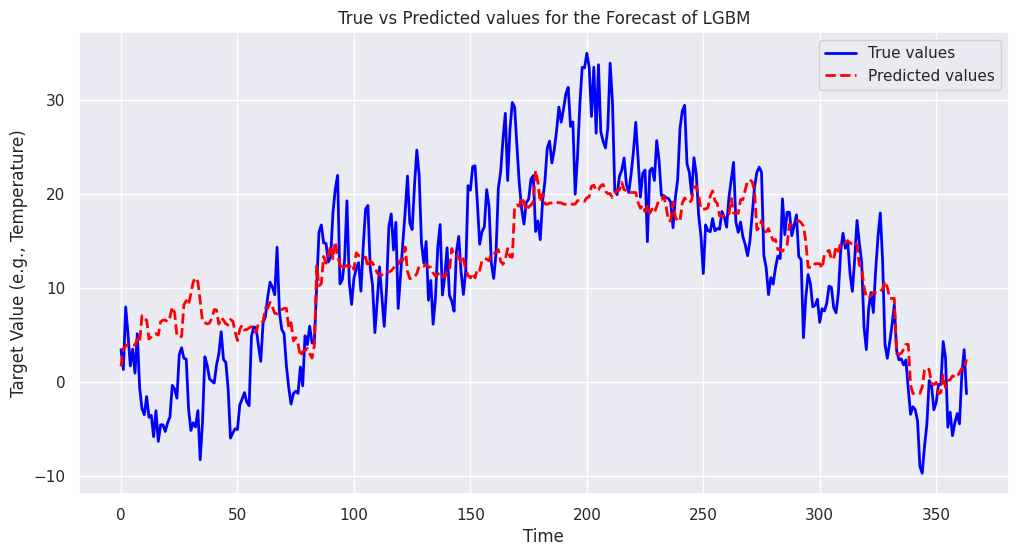

In [35]:
#это для бустинга, MLP видно что показывает хуже результаты
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(y_true_all, label="True values", color='blue', linestyle='-', linewidth=2)
plt.plot(y_pred_all, label="Predicted values", color='red', linestyle='--', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Target Value (e.g., Temperature)')
plt.title('True vs Predicted values for the Forecast of LGBM')
plt.legend()
plt.grid(True)
plt.show()

Переобучите лучшие модели на полном наборе обучающих данных и сделайте ими предсказания на тестовом промежутке. Посчитайте метрики.

Визуализируйте прогнозы, сравнив их с истинными значениями ряда.

#### Задача 8. [1 балл]

Генерировать признаки на этапе знакомства с данными &mdash; не очень интересное занятие.
В отрасли предпринято несколько попыток автоматизировать этот этап.

С помощью библиотеки <a href="https://tsfresh.com/">tsfresh</a> можно довольно быстро сгенерировать большое количество признаков на основе сырых данных временных рядов. Например, по скользящему окну с помощью можно вычислить статистики вида минимум, максимум, среднее, количество пиков и т.д.

Ознакомьтесь с данной библиотекой и сгенерируйте признаковое описание. Обратите внимание на функции
* `roll_time_series`
* `extract_features`

Сколько признаков вы получили? Как побороться с большим числом признаков?

Обучите модель на полном наборе обучающих данных, посчитайте ее качество на тестовых данных и постройте график прогноза в сравнении с истинными значениями.

**Выводы:**

## 5. Модель PatchTST

#### Задача 9. [2.5 балла]

Реализуйте модель [PatchTST](https://arxiv.org/abs/2211.14730).

In [48]:
import torch
import torch.nn as nn
import math


class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.mean = None
        self.std = None
        self.num_features = num_features

    def forward(self, x, mode="norm"):
        if mode == "norm":
            self._calc_statistics(x)
            x = self._normalize(x)
        elif mode == "denorm":
            x = self._denormalize(x)
        return x

    def _calc_statistics(self, x):
        self.mean = x.mean(dim=-1, keepdim=True)
        self.std = x.std(dim=-1, keepdim=True) + self.eps

    def _normalize(self, x):
        return (x - self.mean) / self.std

    def _denormalize(self, x):
        return x * self.std + self.mean


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)  # [1, max_len, d_model]

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)


class PatchTST(nn.Module):
    def __init__(
        self,
        seq_len=336,
        pred_len=96,
        patch_len=16,
        stride=8,
        num_channels=1,
        d_model=128,
        n_heads=4,
        num_layers=3,
        dropout=0.2
    ):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.num_channels = num_channels
        self.pred_len = pred_len

        self.revin = RevIN(num_channels)

        self.patch_num = ((seq_len - patch_len) // stride) + 1
        self.input_proj = nn.Linear(patch_len, d_model)

        self.position_enc = PositionalEncoding(d_model, max_len=self.patch_num)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.output_layer = nn.Linear(d_model, pred_len)


    def create_patches(self, x):
        B, C, T = x.shape
        patches = x.unfold(dimension=2, size=self.patch_len, step=self.stride)
        return patches

    def forward(self, x):
        x = self.revin(x, "norm")
        patches = self.create_patches(x) 
        B, C, N, P = patches.shape

        patches = patches.reshape(B * C, N, P)

        projections = self.input_proj(patches)

        projections = self.position_enc(projections)

        encoded = self.encoder(projections) 

        last_token = encoded[:, -1, :]
        output = self.output_layer(last_token) 

        output = output.view(B, C, self.pred_len)

        output = self.revin(output, "denorm")

        return output


Проверим, что модель работает.

In [50]:
model = PatchTST(
    seq_len=384,
    pred_len=1,
    patch_len=16,
    stride=8,
    num_channels=3,
    d_model=64,
    n_heads=4,
    num_layers=3
)

input_tensor = torch.randn(32, 3, 384)  # [batch, channels, seq_len]
output = model(input_tensor)  # [32, 3, 1]
output.size()

torch.Size([32, 3, 1])

In [52]:
X_train = X_train[['p (mbar)', 'T (degC)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']]
X_test = X_test[['p (mbar)', 'T (degC)', 'rh (%)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']]
mean = X_train.mean()
std = X_train.std()

X = (X_train - mean) / std
X_t = (X_test - mean) / std

In [257]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class SequenceDataset(Dataset):
    def __init__(self, X, y, seq_len=30, pred_len=1):
        self.X = X.values.astype(np.float32)
        self.y = y.values.astype(np.float32)
        self.seq_len = seq_len
        self.pred_len = pred_len

    def __len__(self):
        return len(self.X) - self.seq_len - self.pred_len + 1

    def __getitem__(self, idx):
        x_seq = self.y[idx : idx + self.seq_len]  # использовать только температуру
        y_target = self.y[idx + self.seq_len : idx + self.seq_len + self.pred_len]
        return torch.tensor(x_seq).unsqueeze(0), torch.tensor(y_target) 

        
seq_len = 30
pred_len = 1
batch_size = 32

train_ds = SequenceDataset(X_train, y_train, seq_len, pred_len)
test_ds = SequenceDataset(X_test, y_test, seq_len, pred_len)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size)
device = "cuda" if torch.cuda.is_available() else "cpu"
model = PatchTST(
    seq_len=30,
    pred_len=1,
    patch_len=8,
    stride=4,
    num_channels=1,   # только y
    d_model=64,
    n_heads=4,
    num_layers=3
).to(device)


import torch.nn as nn
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 40

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        output = model(x_batch)
        loss = criterion(output.squeeze(), y_batch.squeeze())
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    print(f"Epoch {epoch+1}: Train Loss = {train_loss / len(train_loader):.4f}")


Epoch 1: Train Loss = 22.0518
Epoch 2: Train Loss = 18.5754
Epoch 3: Train Loss = 17.4393
Epoch 4: Train Loss = 16.7182
Epoch 5: Train Loss = 15.8300
Epoch 6: Train Loss = 15.7859
Epoch 7: Train Loss = 15.8850
Epoch 8: Train Loss = 15.1266
Epoch 9: Train Loss = 14.5766
Epoch 10: Train Loss = 14.8180
Epoch 11: Train Loss = 14.3334
Epoch 12: Train Loss = 14.5307
Epoch 13: Train Loss = 14.5616
Epoch 14: Train Loss = 14.6072
Epoch 15: Train Loss = 13.6971
Epoch 16: Train Loss = 13.7246
Epoch 17: Train Loss = 13.6169
Epoch 18: Train Loss = 13.5792
Epoch 19: Train Loss = 13.2630
Epoch 20: Train Loss = 13.4209
Epoch 21: Train Loss = 12.8712
Epoch 22: Train Loss = 12.4067
Epoch 23: Train Loss = 12.2085
Epoch 24: Train Loss = 12.3701
Epoch 25: Train Loss = 12.0935
Epoch 26: Train Loss = 11.8378
Epoch 27: Train Loss = 11.6537
Epoch 28: Train Loss = 11.8909
Epoch 29: Train Loss = 11.0693
Epoch 30: Train Loss = 11.7645
Epoch 31: Train Loss = 11.5466
Epoch 32: Train Loss = 11.0866
Epoch 33: Train L

#### Задача 10. [1 балл]

Обучите реализованную модель на полном наборе обучающих данных.

In [258]:
model.eval()
test_preds = []
test_targets = []

with torch.no_grad():
    for x_batch, y_batch in test_loader:
        x_batch = x_batch.to(device)
        output = model(x_batch)
        test_preds.append(output.cpu())
        test_targets.append(y_batch)

test_preds = torch.cat(test_preds).squeeze().numpy()
test_targets = torch.cat(test_targets).squeeze().numpy()

from sklearn.metrics import mean_squared_error
print("Test MSE:", mean_squared_error(test_targets, test_preds))


Test MSE: 18.189947


Посчитайте качество на тестовых данных и постройте график прогноза в сравнении с истинными значениями.

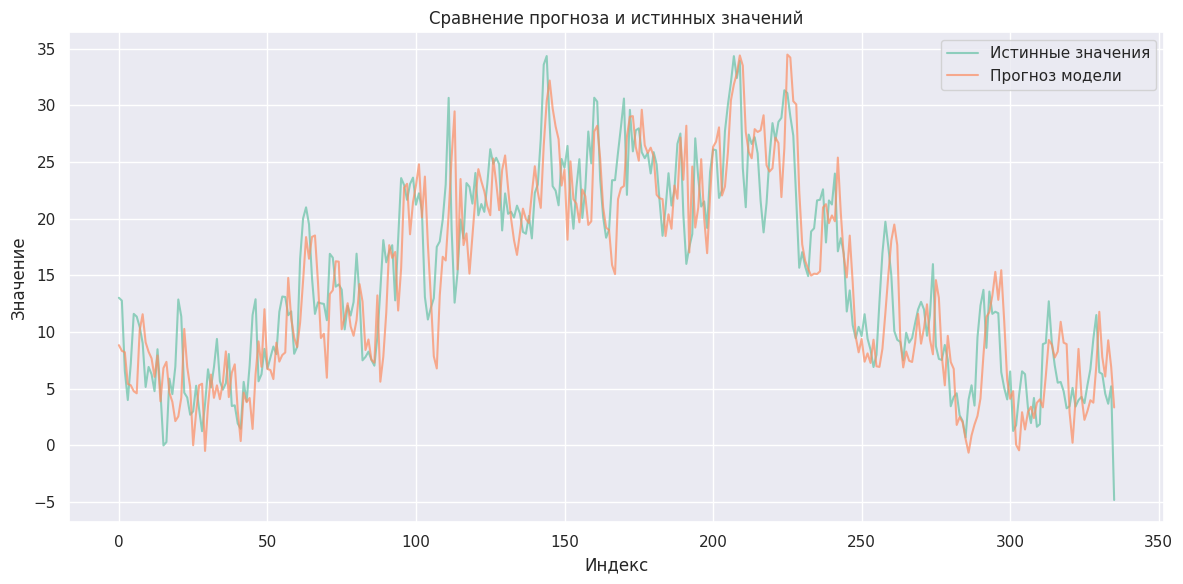

In [259]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(test_targets, label='Истинные значения', alpha=0.7)
plt.plot(test_preds, label='Прогноз модели', alpha=0.7)
plt.title('Сравнение прогноза и истинных значений')
plt.xlabel('Индекс')
plt.ylabel('Значение')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Выводы:**

## 6. Итоговое сравнение

#### Задача 11. [0.25 балла]

Составьте итоговую таблицу сравнения качества прогнозов всех рассмотренных моделей по всем метрикам. Постройте график прогнозов для лучших моделей.

**Выводы:**